In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df_pca = pd.read_csv("../data/PCA_3D_Data.csv")  

X = df_pca[['PC1', 'PC2', 'PC3']].values

range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avgs = {}

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_avgs[n_clusters] = silhouette_avg
    print(f"For n_clusters = {n_clusters}, average silhouette score = {silhouette_avg:.3f}")

best_ks = sorted(silhouette_avgs, key=silhouette_avgs.get, reverse=True)[:3]
print("\nChosen k values based on silhouette scores:", best_ks)



For n_clusters = 2, average silhouette score = 0.391
For n_clusters = 3, average silhouette score = 0.284
For n_clusters = 4, average silhouette score = 0.262
For n_clusters = 5, average silhouette score = 0.300
For n_clusters = 6, average silhouette score = 0.290
For n_clusters = 7, average silhouette score = 0.276
For n_clusters = 8, average silhouette score = 0.290

Chosen k values based on silhouette scores: [2, 5, 8]


In [9]:
#Putting Labels back in

df_original = pd.read_csv("../data/PRE_PCA.csv")

df_pca["placement"] = df_original["placement"]

df_pca.head()

,PC1,PC2,PC3,placement
0,-1.100680,1.206206,2.171129,5
1,-3.756480,-0.862198,0.323565,8
2,-1.916289,-0.754307,0.458250,6
3,0.336231,-0.875288,0.122220,4
4,-2.167720,-0.884619,0.313677,7


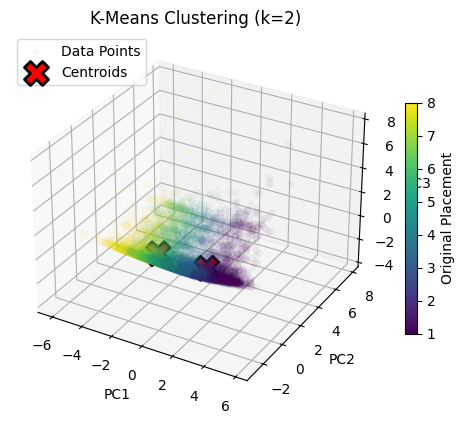

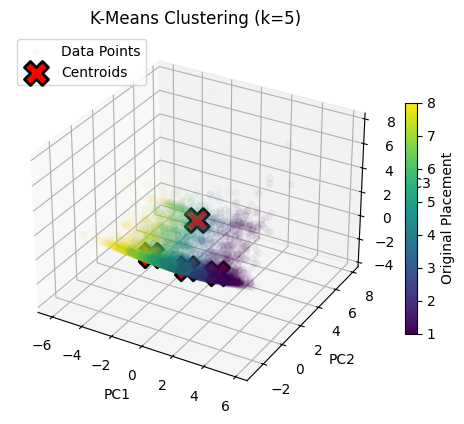

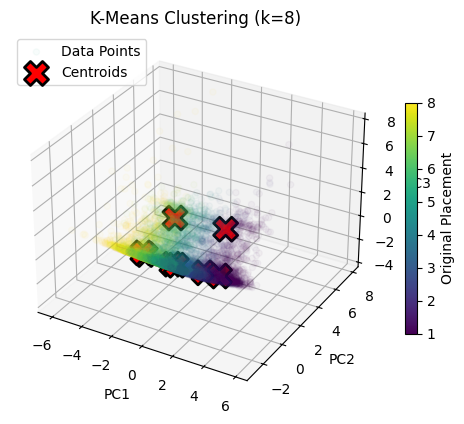

In [ ]:
#K-Means & Plotting
k_values = [2, 5, 8]

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    cluster_labels = km.fit_predict(X)


    centroids = km.cluster_centers_

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        df_pca['PC1'], 
        df_pca['PC2'], 
        df_pca['PC3'],
        c=df_pca['placement'],      
        cmap='viridis',
        alpha=0.03,
        label='Data Points'
    )

    
    ax.scatter(
        centroids[:, 0],
        centroids[:, 1],
        centroids[:, 2],
        c='red',          
        s=300,            
        marker='X',       
        edgecolors='black',  
        linewidths=2,
        alpha=1,        
        zorder=10,        
        label='Centroids'
    )

    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(f'K-Means Clustering (k={k})')

    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
    cbar.set_label('Original Placement')
    cbar.solids.set_alpha(1)

    
    plt.legend(loc='upper left')
    plt.show()

In [20]:
df_pca = pd.read_csv("../data/PCA_3D_Data.csv") 

df_pca.head()

,PC1,PC2,PC3
0,-1.100680,1.206206,2.171129
1,-3.756480,-0.862198,0.323565
2,-1.916289,-0.754307,0.458250
3,0.336231,-0.875288,0.122220
4,-2.167720,-0.884619,0.313677


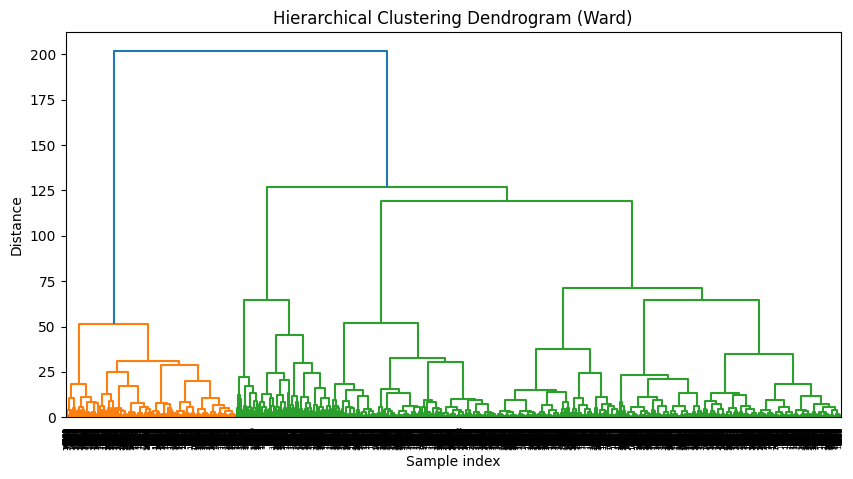

In [ ]:
# For hierarchical clustering and dendrogram:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

num_clusters = 2
cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')

DBSCAN found 5 clusters (excluding outliers).
Number of outliers (label = -1): 247


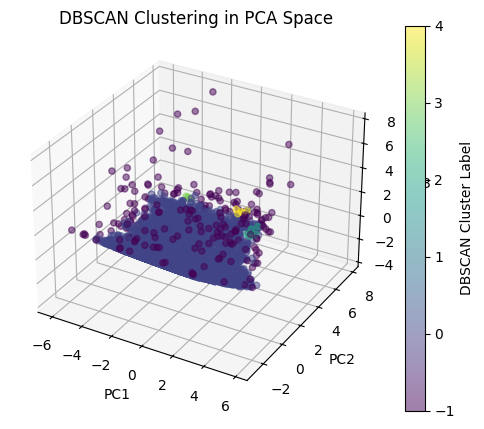

In [28]:
#DBSCAN

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

df_pca['dbscan_label'] = dbscan_labels

unique_labels = set(dbscan_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_outliers = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_clusters} clusters (excluding outliers).")
print(f"Number of outliers (label = -1): {n_outliers}")

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X[:, 0],
    X[:, 1],
    X[:, 2],
    c=dbscan_labels,
    cmap='viridis',
    alpha=0.5
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title("DBSCAN Clustering in PCA Space")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('DBSCAN Cluster Label')

plt.show()